# CIC-IDS2017 Network Traffic — Data Preparation

## Task 1: Data Preparation

This project focuses on preparing the CIC-IDS2017 network traffic dataset
for further data science and machine learning analysis.

### Objectives
- Understand the dataset structure
- Clean column names
- Handle missing values
- Handle infinite values
- Correct data types
- Remove duplicate records
- Clean and validate attack labels
- Identify numerical and categorical features
- Analyze class imbalance
- Document preprocessing decisions

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [72]:
from google.colab import files
uploaded = files.upload()

Saving Tuesday-WorkingHours.pcap_ISCX.csv to Tuesday-WorkingHours.pcap_ISCX.csv


In [75]:
file_name = next(iter(uploaded))

df = pd.read_csv(file_name, low_memory=False)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [42]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 445909
Columns: 79


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,88,640,7,4,440,358,220,0,62.857143,107.349008,179,0,89.5,103.345698,1246875.000,17187.500000,64.000000,135.557286,445,1,640,106.666667,194.325157,497,1,538,179.333333,303.686242,530,4,0,0,0,0,164,104,10937.500000,6250.000000,0,220,66.500000,99.001837,9801.363636,0,0,0,1,0,0,0,0,0,72.545455,62.857143,89.5,164,0,0,0,0,0,0,7,440,4,358,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,88,900,9,4,600,2944,300,0,66.666667,132.287566,1472,0,736.0,849.859596,3937777.778,14444.444440,75.000000,192.795228,684,1,900,112.500000,252.411229,734,1,766,255.333333,435.323252,758,3,0,0,0,0,204,104,10000.000000,4444.444444,0,1472,253.142857,527.434262,278186.901100,0,0,0,1,0,0,0,0,0,272.615385,66.666667,736.0,204,0,0,0,0,0,0,9,600,4,2944,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1205,7,4,2776,2830,1388,0,396.571429,677.274651,1415,0,707.5,816.950631,4652282.158,9128.630705,120.500000,236.433336,777,1,1205,200.833333,397.058392,1008,1,927,309.000000,491.647231,876,1,0,0,0,0,164,104,5809.128631,3319.502075,0,1415,467.166667,690.098917,476236.515200,0,0,0,1,0,0,0,0,0,509.636364,396.571429,707.5,164,0,0,0,0,0,0,7,2776,4,2830,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,88,511,7,4,452,370,226,0,64.571429,110.276708,185,0,92.5,106.809800,1608610.568,21526.418790,51.100000,90.767652,299,1,511,85.166667,131.900594,349,1,462,154.000000,224.719826,412,1,0,0,0,0,164,104,13698.630140,7827.788650,0,226,68.500000,101.933579,10390.454550,0,0,0,1,0,0,0,0,0,74.727273,64.571429,92.5,164,0,0,0,0,0,0,7,452,4,370,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,773,9,4,612,2944,306,0,68.000000,134.933317,1472,0,736.0,849.859596,4600258.732,16817.593790,64.416667,148.698266,531,1,773,96.625000,196.665733,580,1,675,225.000000,348.901132,627,1,0,0,0,0,204,104,11642.949550,5174.644243,0,1472,254.000000,527.520762,278278.153800,0,0,0,1,0,0,0,0,0,273.538461,68.000000,736.0,204,0,0,0,0,0,0,9,612,4,2944,8192,2053,2,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445909 entries, 0 to 445908
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             445909 non-null  int64  
 1    Flow Duration                445909 non-null  int64  
 2    Total Fwd Packets            445909 non-null  int64  
 3    Total Backward Packets       445909 non-null  int64  
 4   Total Length of Fwd Packets   445909 non-null  int64  
 5    Total Length of Bwd Packets  445909 non-null  int64  
 6    Fwd Packet Length Max        445909 non-null  int64  
 7    Fwd Packet Length Min        445909 non-null  int64  
 8    Fwd Packet Length Mean       445909 non-null  float64
 9    Fwd Packet Length Std        445909 non-null  float64
 10  Bwd Packet Length Max         445909 non-null  int64  
 11   Bwd Packet Length Min        445909 non-null  int64  
 12   Bwd Packet Length Mean       445909 non-nul

In [44]:
bad_columns = [col for col in df.columns if col != col.strip()]

print("Columns with extra spaces:", len(bad_columns))
print(bad_columns)

Columns with extra spaces: 65
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag Count', ' CWE Flag Count', ' ECE Flag Count', ' Down/Up Ratio', ' Average Packet Size', ' Avg Fwd Segment Size', ' Avg Bwd Segme

In [45]:
df.columns = df.columns.str.strip()
print("Column names cleaned successfully.")

Column names cleaned successfully.


In [46]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

print("\nTotal missing values:", df.isnull().sum().sum())

Columns with missing values:
Flow Bytes/s    201
dtype: int64

Total missing values: 201


In [47]:
missing_flow = df[df['Flow Bytes/s'].isna()]

print("Rows with missing Flow Bytes/s:", len(missing_flow))

missing_flow[['Flow Duration',
              'Total Length of Fwd Packets',
              'Total Length of Bwd Packets',
              'Flow Bytes/s',
              'Label']].head(10)

Rows with missing Flow Bytes/s: 201


,Flow Duration,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Label
90,0,0,0,NaN,BENIGN
127,0,0,0,NaN,BENIGN
136,0,0,0,NaN,BENIGN
196,0,0,0,NaN,BENIGN
1429,0,0,0,NaN,BENIGN
2278,0,0,0,NaN,BENIGN
2470,0,0,0,NaN,BENIGN
3382,0,0,0,NaN,BENIGN
3572,0,0,0,NaN,BENIGN
5390,0,0,0,NaN,BENIGN


In [48]:
missing_flow = df[df['Flow Bytes/s'].isna()]

print("Missing Flow Bytes/s rows:", len(missing_flow))
print("Non-zero Flow Duration:",
      (missing_flow['Flow Duration'] != 0).sum())
print("Non-zero Forward Bytes:",
      (missing_flow['Total Length of Fwd Packets'] != 0).sum())
print("Non-zero Backward Bytes:",
      (missing_flow['Total Length of Bwd Packets'] != 0).sum())

Missing Flow Bytes/s rows: 201
Non-zero Flow Duration: 0
Non-zero Forward Bytes: 0
Non-zero Backward Bytes: 0


In [49]:
df['Flow Bytes/s'] = df['Flow Bytes/s'].fillna(0)
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [50]:
numeric_cols = df.select_dtypes(include=np.number).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
inf_counts = inf_counts[inf_counts > 0].sort_values(ascending=False)

print("Columns with infinite values:")
print(inf_counts)

print("\nTotal infinite values:", inf_counts.sum())

Columns with infinite values:
Flow Packets/s    264
Flow Bytes/s       63
dtype: int64

Total infinite values: 327


In [51]:
inf_rows = df[
    np.isinf(df['Flow Packets/s']) |
    np.isinf(df['Flow Bytes/s'])
]

print("Rows containing infinite values:", len(inf_rows))

inf_rows[
    ['Flow Duration',
     'Total Fwd Packets',
     'Total Backward Packets',
     'Total Length of Fwd Packets',
     'Total Length of Bwd Packets',
     'Flow Packets/s',
     'Flow Bytes/s',
     'Label']
].head(10)

Rows containing infinite values: 264


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Packets/s,Flow Bytes/s,Label
90,0,1,1,0,0,inf,0.0,BENIGN
127,0,2,0,0,0,inf,0.0,BENIGN
136,0,2,0,0,0,inf,0.0,BENIGN
167,0,2,0,7,0,inf,inf,BENIGN
172,0,2,0,7,0,inf,inf,BENIGN
196,0,1,1,0,0,inf,0.0,BENIGN
1429,0,1,1,0,0,inf,0.0,BENIGN
2278,0,2,0,0,0,inf,0.0,BENIGN
2439,0,2,0,31,0,inf,inf,BENIGN
2470,0,2,0,0,0,inf,0.0,BENIGN


In [52]:
inf_rows = df[
    np.isinf(df['Flow Packets/s']) |
    np.isinf(df['Flow Bytes/s'])
]

print("Rows with infinite values:", len(inf_rows))

print("Rows with zero Flow Duration:",
      (inf_rows['Flow Duration'] == 0).sum())

print("Rows with non-zero Flow Duration:",
      (inf_rows['Flow Duration'] != 0).sum())

Rows with infinite values: 264
Rows with zero Flow Duration: 264
Rows with non-zero Flow Duration: 0


In [53]:
inf_mask = (
    np.isinf(df['Flow Packets/s']) |
    np.isinf(df['Flow Bytes/s'])
)

df = df[~inf_mask].copy()
print("Rows removed:", inf_mask.sum())
print("New dataset shape:", df.shape)

Rows removed: 264
New dataset shape: (445645, 79)


In [54]:
print("Infinite values remaining:",
      np.isinf(df.select_dtypes(include=np.number)).sum().sum())

print("Missing values remaining:",
      df.isnull().sum().sum())

Infinite values remaining: 0
Missing values remaining: 0


In [55]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 24019


In [56]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)

print("Duplicate rows removed:", before - after)
print("Rows remaining:", after)

Duplicate rows removed: 24019
Rows remaining: 421626


In [57]:
print(df.dtypes.value_counts())

int64      54
float64    24
object      1
Name: count, dtype: int64


In [58]:
non_numeric = df.select_dtypes(exclude=np.number).columns.tolist()
print("Non-numeric columns:")
print(non_numeric)

Non-numeric columns:
['Label']


In [59]:
print("Unique labels:")
print(df['Label'].unique())

Unique labels:
['BENIGN' 'FTP-Patator' 'SSH-Patator']


In [60]:
label_counts = df['Label'].value_counts()
print(label_counts)

Label
BENIGN         412476
FTP-Patator      5931
SSH-Patator      3219
Name: count, dtype: int64


In [61]:
labels_with_spaces = df['Label'].astype(str).apply(
    lambda x: x != x.strip()
).sum()
print("Labels with extra spaces:", labels_with_spaces)

Labels with extra spaces: 0


In [62]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 78
Number of categorical features: 1

Categorical features:
['Label']


In [63]:
class_counts = df['Label'].value_counts()
class_percentages = (df['Label'].value_counts(normalize=True) * 100).round(2)

class_distribution = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages
})
class_distribution

,Count,Percentage
Label,,
BENIGN,412476,97.83
FTP-Patator,5931,1.41
SSH-Patator,3219,0.76


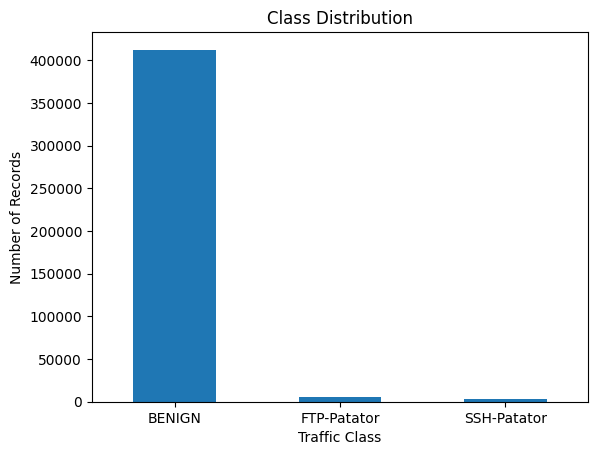

In [64]:
class_counts.plot(kind='bar')

plt.title('Class Distribution')
plt.xlabel('Traffic Class')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

### Class Imbalance Observation

The dataset is highly imbalanced, with BENIGN traffic representing the
majority of observations, while FTP-Patator and SSH-Patator attack traffic
represent much smaller classes.

This imbalance is documented during data preparation and will be considered
during the modeling stage. No resampling or balancing technique is applied
at this stage to preserve the original distribution of the dataset.

In [73]:
# Final Data Quality Audit

print("===== FINAL DATA QUALITY AUDIT =====")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:",
      df.isnull().sum().sum())

print("Infinite values:",
      np.isinf(df.select_dtypes(include=np.number)).sum().sum())

print("Duplicate rows:",
      df.duplicated().sum())

print("Unique labels:",
      df['Label'].nunique())

print("\nLabels:")
print(df['Label'].value_counts())

===== FINAL DATA QUALITY AUDIT =====
Rows: 421626
Columns: 79

Missing values: 0
Infinite values: 0
Duplicate rows: 0
Unique labels: 3

Labels:
Label
BENIGN         412476
FTP-Patator      5931
SSH-Patator      3219
Name: count, dtype: int64


In [66]:
output_file = "CIC_IDS2017_Tuesday_Cleaned.csv"
df.to_csv(output_file, index=False)

print("Cleaned dataset saved successfully!")
print("File:", output_file)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Cleaned dataset saved successfully!
File: CIC_IDS2017_Tuesday_Cleaned.csv
Rows: 421626
Columns: 79


In [67]:
from google.colab import files
files.download("CIC_IDS2017_Tuesday_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Preprocessing Summary

The CIC-IDS2017 Tuesday dataset was prepared for downstream data science
and machine learning analysis.

### Dataset Statistics

- Original records: 445,909
- Final records: 421,626
- Original features: 79
- Final features: 79

### Cleaning Performed

- Removed leading/trailing whitespace from 65 column names.
- Handled 201 missing values in `Flow Bytes/s` after investigating their
  underlying flow characteristics.
- Identified 327 infinite values across `Flow Packets/s` and `Flow Bytes/s`.
- The infinite values occurred in 264 records, all with zero flow duration.
  These records were removed because the corresponding rate calculations
  were undefined.
- Removed 24,019 duplicate records.
- Validated the three traffic labels: `BENIGN`, `FTP-Patator`, and
  `SSH-Patator`.
- Confirmed that 78 network-flow features are numeric and `Label` is
  categorical.
- Identified significant class imbalance, with BENIGN traffic representing
  the majority class.
- No resampling or class-balancing technique was applied during data
  preparation.

In [68]:
print("CLEANED DATASET READY")
print("----------------------")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

CLEANED DATASET READY
----------------------
Rows: 421,626
Columns: 79
Missing values: 0
Infinite values: 0
Duplicate rows: 0
